<a href="https://colab.research.google.com/github/nikhilRajput-prog/Deep-Learning-Lab-File/blob/main/deep_learning_exp_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wandb -q

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import wandb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
IMG_SIZE = 32

transform_basic = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_basic)

# Split 80/10/10
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128)
test_loader = DataLoader(test_data, batch_size=128)

100%|██████████| 170M/170M [00:03<00:00, 48.6MB/s]


In [3]:
EPOCHS = 5
LR = 3e-4

MODEL_TYPE = "ViT"   # "ViT" or "ResNet"
LOSS_TYPE = "CE"     # "CE", "LS", "FOCAL"
OPTIMIZER = "Adam"   # "Adam", "SGD", "RMSprop"

USE_AUGMENT = False

In [4]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, embed_dim=128):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(3, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)  # (B, E, H, W)
        x = x.flatten(2).transpose(1, 2)
        return x

In [5]:
class ViT(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4, depth=4, num_classes=10):
        super().__init__()

        self.patch_embed = PatchEmbedding()
        num_patches = self.patch_embed.n_patches

        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=256,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)

        B = x.size(0)
        cls_tokens = self.cls_token.expand(B, -1, -1)

        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed

        x = self.transformer(x)
        cls = x[:, 0]

        return self.fc(cls)

In [6]:
def get_resnet():
    model = resnet18(pretrained=False)
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model

In [7]:
if MODEL_TYPE == "ViT":
    model = ViT().to(device)
else:
    model = get_resnet().to(device)

In [8]:
ce_loss = nn.CrossEntropyLoss()

class LabelSmoothingLoss(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, pred, target):
        log_prob = torch.log_softmax(pred, dim=-1)
        n_classes = pred.size(1)

        true_dist = torch.zeros_like(pred)
        true_dist.fill_(self.smoothing / (n_classes - 1))
        true_dist.scatter_(1, target.unsqueeze(1), 1 - self.smoothing)

        return torch.mean(torch.sum(-true_dist * log_prob, dim=1))

class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma

    def forward(self, pred, target):
        ce = nn.functional.cross_entropy(pred, target, reduction='none')
        pt = torch.exp(-ce)
        return torch.mean((1 - pt) ** self.gamma * ce)

if LOSS_TYPE == "CE":
    criterion = ce_loss
elif LOSS_TYPE == "LS":
    criterion = LabelSmoothingLoss()
else:
    criterion = FocalLoss()

In [9]:
if OPTIMIZER == "Adam":
    optimizer = optim.Adam(model.parameters(), lr=LR)
elif OPTIMIZER == "RMSprop":
    optimizer = optim.RMSprop(model.parameters(), lr=LR)
else:
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9)

In [10]:
train_losses, val_losses, val_accs = [], [], []

def evaluate(loader):
    model.eval()
    correct, total, loss_total = 0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)

            loss = criterion(out, y)
            loss_total += loss.item()

            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return loss_total / len(loader), correct / total

In [11]:
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        out = model(x)
        loss = criterion(out, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    val_loss, val_acc = evaluate(val_loader)

    train_losses.append(total_loss / len(train_loader))
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Val Acc={val_acc:.4f}")

Epoch 1: Train Loss=1.8920, Val Acc=0.3944
Epoch 2: Train Loss=1.5997, Val Acc=0.4562
Epoch 3: Train Loss=1.4693, Val Acc=0.4856
Epoch 4: Train Loss=1.3889, Val Acc=0.5014
Epoch 5: Train Loss=1.3325, Val Acc=0.5126


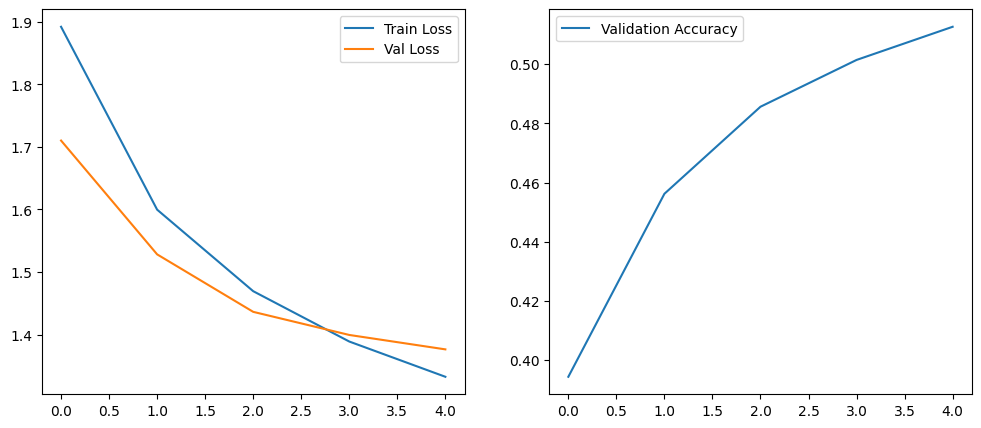

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_accs, label="Validation Accuracy")
plt.legend()

plt.show()

In [13]:
test_loss, test_acc = evaluate(test_loader)
print("Test Accuracy:", test_acc)

Test Accuracy: 0.533


In [14]:
configs = [
    ("ViT", "CE", "Adam"),
    ("ViT", "LS", "Adam"),
    ("ResNet", "CE", "Adam"),
    ("ResNet", "FOCAL", "SGD"),
]

results = []

for m, l, o in configs:
    MODEL_TYPE, LOSS_TYPE, OPTIMIZER = m, l, o

    print(f"\nRunning: {m}, {l}, {o}")

    # Recreate model
    if m == "ViT":
        model = ViT().to(device)
    else:
        model = get_resnet().to(device)

    # Loss
    if l == "CE":
        criterion = ce_loss
    elif l == "LS":
        criterion = LabelSmoothingLoss()
    else:
        criterion = FocalLoss()

    # Optimizer
    if o == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=LR)
    elif o == "RMSprop":
        optimizer = optim.RMSprop(model.parameters(), lr=LR)
    else:
        optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9)

    # Train (short)
    for epoch in range(2):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            loss = criterion(model(x), y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    _, acc = evaluate(test_loader)
    results.append((m, l, o, acc))


Running: ViT, CE, Adam

Running: ViT, LS, Adam

Running: ResNet, CE, Adam


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



Running: ResNet, FOCAL, SGD


In [15]:
for r in results:
    print(f"Model: {r[0]}, Loss: {r[1]}, Opt: {r[2]} -> Test Acc: {r[3]:.4f}")

Model: ViT, Loss: CE, Opt: Adam -> Test Acc: 0.4618
Model: ViT, Loss: LS, Opt: Adam -> Test Acc: 0.4658
Model: ResNet, Loss: CE, Opt: Adam -> Test Acc: 0.6014
Model: ResNet, Loss: FOCAL, Opt: SGD -> Test Acc: 0.4408
